In [1]:
import pandas as pd

df = pd.read_csv("plant_vase1(2).csv")
df.head()

,year,month,day,hour,minute,second,moisture0,moisture1,moisture2,moisture3,moisture4,irrgation
0,2020,3,6,22,16,11,0.33,0.40,0.36,0.23,0.02,False
1,2020,3,6,22,17,11,0.32,0.39,0.35,0.23,0.02,False
2,2020,3,6,22,18,11,0.31,0.39,0.34,0.22,0.02,False
3,2020,3,6,22,19,11,0.30,0.38,0.33,0.21,0.02,False
4,2020,3,6,22,20,11,0.29,0.38,0.33,0.21,0.02,False


## Setup & Data Acquisition

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4409 entries, 0 to 4408
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       4409 non-null   int64  
 1   month      4409 non-null   int64  
 2   day        4409 non-null   int64  
 3   hour       4409 non-null   int64  
 4   minute     4409 non-null   int64  
 5   second     4409 non-null   int64  
 6   moisture0  4409 non-null   float64
 7   moisture1  4409 non-null   float64
 8   moisture2  4409 non-null   float64
 9   moisture3  4409 non-null   float64
 10  moisture4  4409 non-null   float64
 11  irrgation  4409 non-null   bool   
dtypes: bool(1), float64(5), int64(6)
memory usage: 383.3 KB


,year,month,day,hour,minute,second,moisture0,moisture1,moisture2,moisture3,moisture4
count,4409.0,4409.0,4409.000000,4409.000000,4409.000000,4409.000000,4409.000000,4409.000000,4409.000000,4409.000000,4409.000000
mean,2020.0,3.0,7.950102,11.731005,29.526650,29.914947,0.228172,0.414430,0.477097,0.124459,0.026124
std,0.0,0.0,0.861432,7.031253,17.275479,16.480486,0.043375,0.191624,0.062849,0.018743,0.008927
min,2020.0,3.0,6.000000,0.000000,0.000000,0.000000,0.170000,0.140000,0.230000,0.080000,0.010000
25%,2020.0,3.0,7.000000,6.000000,15.000000,16.000000,0.190000,0.290000,0.470000,0.110000,0.020000
50%,2020.0,3.0,8.000000,12.000000,30.000000,30.000000,0.220000,0.390000,0.500000,0.120000,0.020000
75%,2020.0,3.0,9.000000,18.000000,44.000000,44.000000,0.270000,0.450000,0.510000,0.130000,0.030000
max,2020.0,3.0,9.000000,23.000000,59.000000,59.000000,0.360000,0.960000,0.560000,0.240000,0.110000


## Data Processing

In [9]:
df.isnull().sum()
df = df.dropna()

## Data Analysis

In [11]:
df[['moisture0','moisture1','moisture2','moisture3','moisture4']].mean()
df[['moisture0','moisture1','moisture2','moisture3','moisture4']].describe()

,moisture0,moisture1,moisture2,moisture3,moisture4
count,4409.000000,4409.000000,4409.000000,4409.000000,4409.000000
mean,0.228172,0.414430,0.477097,0.124459,0.026124
std,0.043375,0.191624,0.062849,0.018743,0.008927
min,0.170000,0.140000,0.230000,0.080000,0.010000
25%,0.190000,0.290000,0.470000,0.110000,0.020000
50%,0.220000,0.390000,0.500000,0.120000,0.020000
75%,0.270000,0.450000,0.510000,0.130000,0.030000
max,0.360000,0.960000,0.560000,0.240000,0.110000


## Visualization & Dashboard

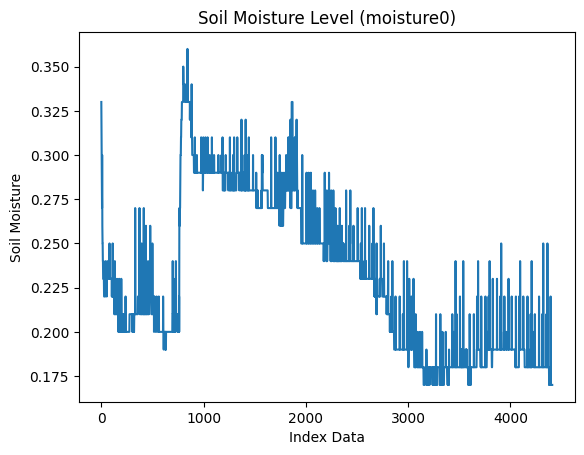

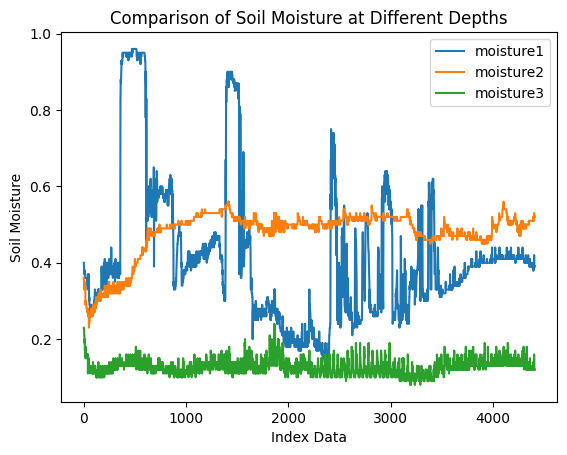

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['moisture0'])
plt.title('Soil Moisture Level (moisture0)')
plt.xlabel('Index Data')
plt.ylabel('Soil Moisture')
plt.show()

plt.figure()
plt.plot(df['moisture1'], label='moisture1')
plt.plot(df['moisture2'], label='moisture2')
plt.plot(df['moisture3'], label='moisture3')
plt.legend()
plt.title('Comparison of Soil Moisture at Different Depths')
plt.xlabel('Index Data')
plt.ylabel('Soil Moisture')
plt.show()

## Documentation & Data Governance

### Documentation
Dataset yang digunakan adalah Soil Moisture Dataset yang diperoleh dari Kaggle.
Dataset ini berisi data kelembaban tanah yang dikumpulkan menggunakan sensor IoT
pada beberapa kedalaman tanah dan dicatat berdasarkan waktu.

Data digunakan untuk keperluan analisis dan visualisasi dalam smart farming,
khususnya untuk membantu monitoring kondisi tanah dan pengambilan keputusan irigasi.

### Data Governance & Data Quality
- Data Ownership: Dataset bersifat publik dan berasal dari Kaggle
- Accuracy: Data diperoleh dari sensor IoT
- Completeness: Data telah diperiksa dan dibersihkan dari missing value
- Consistency: Format data telah diseragamkan
- Timeliness: Data dicatat berdasarkan waktu sehingga relevan untuk monitoring

Dataset ini tidak mengandung data pribadi sehingga aman untuk digunakan.

In [33]:
# Total data
total_cells = df.size
missing_cells = df.isnull().sum().sum()
non_null_cells = total_cells - missing_cells

# Accuracy & Completeness
accuracy = 1 - (missing_cells / total_cells)
completeness = non_null_cells / total_cells

# Timeliness (30 hari terakhir)
# Gabungkan kolom waktu jadi datetime
df['datetime'] = pd.to_datetime(
    df[['year','month','day','hour','minute','second']]
)

latest_date = df['datetime'].max()
last_30_days = latest_date - pd.Timedelta(days=30)

timely_data = df[df['datetime'] >= last_30_days]
timeliness = len(timely_data) / len(df)

accuracy, completeness, timeliness

(np.float64(1.0), np.float64(1.0), 1.0)

In [17]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 102.3 MB/s eta 0:00:00


In [31]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Smart Farming Dashboard")
st.write("Monitoring Soil Moisture Sensor Data")

# Load dataset
df = pd.read_csv("plant_vase1(2).csv")

st.subheader("Dataset Preview")
st.dataframe(df.head())

st.subheader("Soil Moisture Time Series (moisture0)")

fig, ax = plt.subplots()
ax.plot(df['moisture0'])
ax.set_xlabel("Index Data")
ax.set_ylabel("Soil Moisture")
ax.set_title("Soil Moisture Trend Over Time")

st.pyplot(fig)

st.subheader("Current Soil Moisture (moisture0)")

current_moisture = df['moisture0'].iloc[-1]

st.metric(
    label="Soil Moisture Level",
    value=round(current_moisture, 3)
)

st.subheader("Correlation Heatmap (Soil Moisture Sensors)")

# pilih kolom sensor
sensor_cols = ['moisture0','moisture1','moisture2','moisture3','moisture4']
corr = df[sensor_cols].corr()

fig, ax = plt.subplots()
cax = ax.imshow(corr, cmap='coolwarm')

ax.set_xticks(range(len(sensor_cols)))
ax.set_yticks(range(len(sensor_cols)))
ax.set_xticklabels(sensor_cols)
ax.set_yticklabels(sensor_cols)

plt.colorbar(cax)
ax.set_title("Correlation Between Soil Moisture Sensors")

st.pyplot(fig)

st.subheader("Soil Moisture Alert System")

threshold = 0.2
current_moisture = df['moisture0'].iloc[-1]

if current_moisture < threshold:
    st.error(
        f"⚠️ WARNING: Soil moisture is low ({round(current_moisture,3)}). Irrigation needed!"
    )
else:
    st.success(
        f"✅ Soil moisture is normal ({round(current_moisture,3)})."
    )

Overwriting app.py


In [23]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://tomiko-empyreal-better.ngrok-free.dev" -> "http://localhost:8501">

In [22]:
from pyngrok import ngrok
ngrok.set_auth_token("3ARZLmvbXbFGkPsKMFNhBhdu9UA_6NbWEbMEXQYD12Y4LbSKk")

In [32]:
!streamlit run app.py &>/content/logs.txt &